# Step 5: Recommendation Sizing
## Headline Goal
Bring together everything from the prior notebooks - Single Game's lapsed demand, Partial Season's proven growth, and Full Season's price relationship - into one final, sized recommendation. This notebook builds the 3-2-1 Plan's detailed sizing, projects combined attendance forward, and works backward from an overall Partial Season growth target to determine what each lever (organic growth, 3-2-1, 3-6-9) needs to deliver.

### - Establish Visualization Standards

In [1]:
# ============================================================
# Imports & Visualization Standards
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Standard color palette (order: Blue, Red, Teal, Yellow)
PALETTE = ['#0000a2', '#bc272d', '#50ad9f', '#e9c716']

# Standard figure size for all charts
FIGSIZE = (22, 8.5)

# Axis formatters
def thousands_formatter(x, pos):
    return f'{x/1000:,.0f}K'

def millions_formatter(x, pos):
    return f'${x/1_000_000:,.1f}M'

# Standard label styling
TITLE_STYLE = {'fontsize': 15, 'fontweight': 'bold'}
LABEL_STYLE = {'fontsize': 12, 'fontweight': 'bold'}

# Shared constants used across multiple analysis cells
YEARS = [2021, 2022, 2023]
YEAR_COLORS = dict(zip(YEARS, PALETTE))
DOW_ORDER = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
MONTH_ORDER = ['April', 'May', 'June', 'July', 'August', 'September']
DAYNIGHT_ORDER = ['Day Game', 'Night Game']
BAR_WIDTH = 0.25

### - Load in Data

In [2]:
full = pd.read_csv('../step_01_clean_data/clean_data.csv', parse_dates=['Game Date'])

print(f"Loaded: {full.shape[0]} rows, {full.shape[1]} columns")
full.head()

Loaded: 243 rows, 26 columns


,Home Game #,Game Date,Year,Month,Day of Week,Weekend / Weekday,Game Time,Day/Night,Full Season Tickets (#),Full Season Revenue ($),...,Group Avg Price ($),Single Game Tickets (#),Single Game Revenue ($),Single Game Avg Price ($),No-Show Rate,Total Tickets (#),Actual Attendance (#),Total Revenue ($),Average Ticket Price ($),Is First Month
0,1,2021-04-01,2021,April,Thursday,Weekday,13:10:00,Day Game,9361,417794.04,...,46.83,16916,1013906.60,59.94,0.1420,36688,31478,1870492.51,50.98,True
1,2,2021-04-02,2021,April,Friday,Weekend,19:10:00,Night Game,9374,415278.62,...,25.93,9023,272800.32,30.23,0.1752,24520,20224,852818.98,34.78,True
2,3,2021-04-03,2021,April,Saturday,Weekend,18:10:00,Night Game,9398,414149.54,...,30.51,10411,373733.78,35.90,0.1643,28927,24174,1057199.15,36.55,True
3,4,2021-04-04,2021,April,Sunday,Weekend,13:10:00,Day Game,9374,415431.58,...,30.16,12149,411154.96,33.84,0.1609,28561,23966,1057229.43,37.02,True
4,5,2021-04-09,2021,April,Friday,Weekend,19:10:00,Night Game,9376,416211.65,...,30.28,10282,408009.37,39.68,0.1570,29910,25214,1141873.37,38.18,True


## 3-2-1 Plan: Final Sizing, with the Price Uplift Opportunity
### - Working backward from packages sold to keep the fixed 3 Wed + 2 Tue + 1 Mon ratio internally consistent, plus quantifying the extra value captured simply by converting Single Game buyers into higher-paying Partial Season buyers

In [3]:
total_goal = 110601
games_per_package = 6
package_ratio = {'Monday': 1, 'Tuesday': 2, 'Wednesday': 3}

price_2023 = {}
sg_price_2023 = {}
for day in ['Monday','Tuesday','Wednesday']:
    price_2023[day] = full[(full['Day of Week']==day) & (full['Year']==2023)]['Partial Season Avg Price ($)'].mean()
    sg_price_2023[day] = full[(full['Day of Week']==day) & (full['Year']==2023)]['Single Game Avg Price ($)'].mean()
price_growth = {'Monday': 0.122, 'Tuesday': 0.128, 'Wednesday': 0.130}
orig_gaps = {'Monday': 25703, 'Tuesday': 41807, 'Wednesday': 43091}

# Price uplift per ticket (Partial Season vs. Single Game, both at 2023 levels - the pure conversion value)
price_uplift = {day: price_2023[day] - sg_price_2023[day] for day in package_ratio}

print("=== Price Uplift per Recovered Ticket (Partial Season vs. Single Game, 2023) ===")
for day, gap in price_uplift.items():
    pct = gap/sg_price_2023[day]*100
    print(f"{day}: ${gap:.2f}/ticket ({pct:.0f}% premium over what they paid as Single Game buyers)")

print("\n=== 3-2-1 Plan: Final Sizing ===")
summary_rows = []
for yr in [1,2,3]:
    packages = (total_goal*(yr/3))/games_per_package
    total_rev = 0
    total_uplift_value = 0
    print(f"\nYear {2023+yr}: {packages:,.0f} packages sold")
    for day, ratio in package_ratio.items():
        delivered = packages*ratio
        price = price_2023[day]*(1+price_growth[day])**yr
        rev = delivered*price
        uplift_value = delivered*price_uplift[day]  # value captured vs. Single Game pricing, at 2023 uplift levels
        total_rev += rev
        total_uplift_value += uplift_value
        pct_of_own_gap = delivered/(orig_gaps[day]*(yr/3))*100
        print(f"   {day}: {delivered:,.0f} tickets ({pct_of_own_gap:.0f}% of own gap) @ ${price:.2f} = ${rev:,.0f} | price uplift value: ${uplift_value:,.0f}")
        summary_rows.append({'Year': 2023+yr, 'Day': day, 'Tickets': f'{delivered:,.0f}', 'Price': f'${price:.2f}', 'Revenue': f'${rev:,.0f}', 'Uplift Value': f'${uplift_value:,.0f}'})
    print(f"   TOTAL: {packages*games_per_package:,.0f} tickets, ${total_rev:,.0f} revenue, ${total_uplift_value:,.0f} of which is pure price uplift")

print("\n")
print(pd.DataFrame(summary_rows).to_string(index=False))

=== Price Uplift per Recovered Ticket (Partial Season vs. Single Game, 2023) ===
Monday: $16.89/ticket (106% premium over what they paid as Single Game buyers)
Tuesday: $18.29/ticket (118% premium over what they paid as Single Game buyers)
Wednesday: $11.65/ticket (58% premium over what they paid as Single Game buyers)

=== 3-2-1 Plan: Final Sizing ===

Year 2024: 6,144 packages sold
   Monday: 6,144 tickets (72% of own gap) @ $36.78 = $225,971 | price uplift value: $103,803
   Tuesday: 12,289 tickets (88% of own gap) @ $38.16 = $468,919 | price uplift value: $224,813
   Wednesday: 18,434 tickets (128% of own gap) @ $35.89 = $661,540 | price uplift value: $214,679
   TOTAL: 36,867 tickets, $1,356,430 revenue, $543,295 of which is pure price uplift

Year 2025: 12,289 packages sold
   Monday: 12,289 tickets (72% of own gap) @ $41.26 = $507,078 | price uplift value: $207,606
   Tuesday: 24,578 tickets (88% of own gap) @ $43.04 = $1,057,882 | price uplift value: $449,626
   Wednesday: 36,8

**Key Findings:**
- Every recovered ticket is worth substantially more as a Partial Season sale than it ever was as a Single Game sale which is a distinct value driver from volume recovery alone
- By Year 3, a meaningful share of 3-2-1's total revenue is attributable to this pure price uplift, not just the underlying ticket recovery

## Combined Attendance Outlook: Single Game + Partial Season, by Day (2021-2026)
### - Single Game continues declining at a tapered rate off its actual 2022-2023 trend; Partial Season grows per the 3-2-1 recovery model. Together, this shows the realistic net attendance picture per game

/var/folders/rv/p8vzwm1d68n147ykhgm42q0c0000gn/T/ipykernel_85913/2607645727.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(years_labels, rotation=45)
/var/folders/rv/p8vzwm1d68n147ykhgm42q0c0000gn/T/ipykernel_85913/2607645727.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(years_labels, rotation=45)
/var/folders/rv/p8vzwm1d68n147ykhgm42q0c0000gn/T/ipykernel_85913/2607645727.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(years_labels, rotation=45)


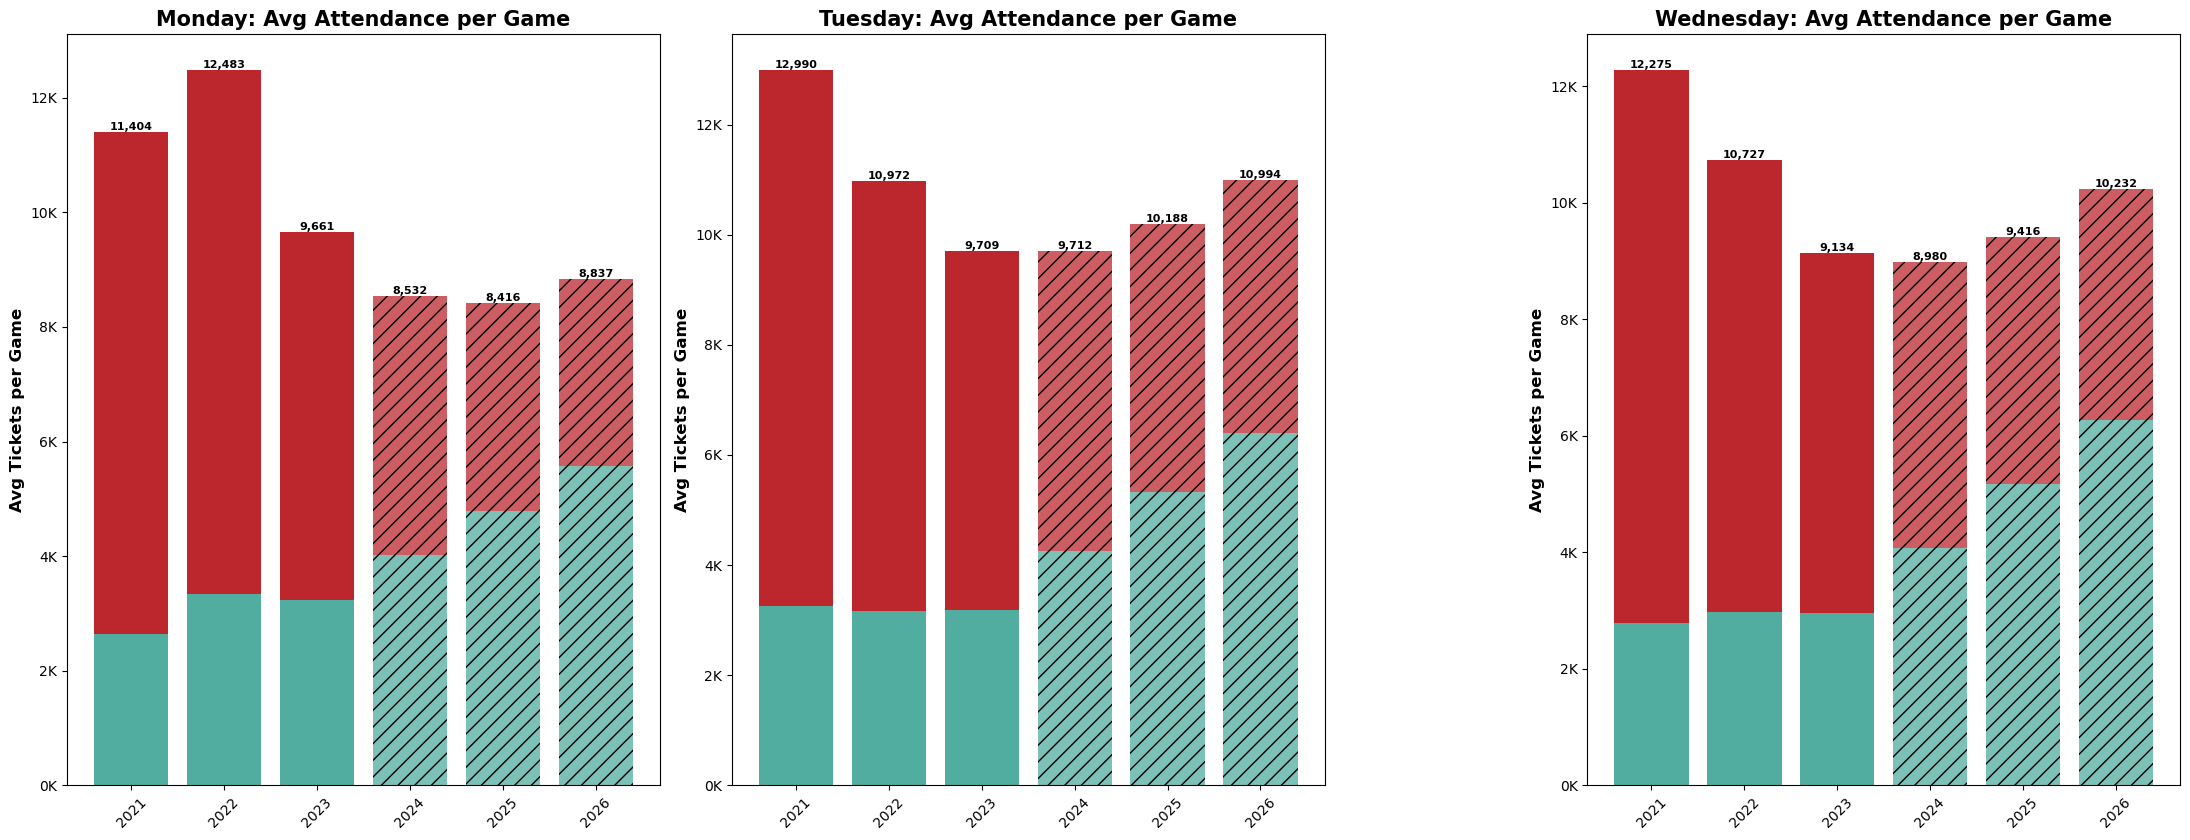

      Day  Year Single Game Partial Season  Total
   Monday  2021       8,761          2,643 11,404
   Monday  2022       9,140          3,343 12,483
   Monday  2023       6,424          3,236  9,661
   Monday  2024       4,516          4,015  8,532
   Monday  2025       3,622          4,794  8,416
   Monday  2026       3,264          5,573  8,837
  Tuesday  2021       9,736          3,254 12,990
  Tuesday  2022       7,803          3,169 10,972
  Tuesday  2023       6,520          3,189  9,709
  Tuesday  2024       5,451          4,261  9,712
  Tuesday  2025       4,855          5,333 10,188
  Tuesday  2026       4,589          6,405 10,994
Wednesday  2021       9,489          2,787 12,275
Wednesday  2022       7,757          2,969 10,727
Wednesday  2023       6,174          2,960  9,134
Wednesday  2024       4,914          4,065  8,980
Wednesday  2025       4,246          5,170  9,416
Wednesday  2026       3,957          6,275 10,232


In [4]:
sg_decline_rate = {'Monday': -0.297, 'Tuesday': -0.164, 'Wednesday': -0.204}
taper_fractions = {1: 1.0, 2: 2/3, 3: 1/3}
total_goal_gaps = {'Monday': 25703, 'Tuesday': 41807, 'Wednesday': 43091}
games_2023 = {'Monday': 11, 'Tuesday': 13, 'Wednesday': 13}

actual_sg, actual_ps = {}, {}
for day in ['Monday','Tuesday','Wednesday']:
    d = full[full['Day of Week']==day]
    actual_sg[day] = d.groupby('Year')['Single Game Tickets (#)'].mean().to_dict()
    actual_ps[day] = d.groupby('Year')['Partial Season Tickets (#)'].mean().to_dict()

projections = {}
for day in ['Monday','Tuesday','Wednesday']:
    sg_series = {2021: actual_sg[day][2021], 2022: actual_sg[day][2022], 2023: actual_sg[day][2023]}
    ps_series = {2021: actual_ps[day][2021], 2022: actual_ps[day][2022], 2023: actual_ps[day][2023]}
    sg_running = actual_sg[day][2023]
    for yr in [1,2,3]:
        year_num = 2023+yr
        yr_rate = sg_decline_rate[day]*taper_fractions[yr]
        sg_running = sg_running*(1+yr_rate)
        sg_series[year_num] = sg_running
        ps_recovery_per_game = (yr/3) * (total_goal_gaps[day]/games_2023[day])
        ps_series[year_num] = actual_ps[day][2023] + ps_recovery_per_game
    projections[day] = {'sg': sg_series, 'ps': ps_series}

all_years = [2021, 2022, 2023, 2024, 2025, 2026]
years_labels = [str(y) for y in all_years]

fig = plt.figure(figsize=FIGSIZE)
gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 0.2, 1])
ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1])
ax_gap = fig.add_subplot(gs[2])
ax2 = fig.add_subplot(gs[3])
ax_gap.axis('off')

axes_list = [ax0, ax1, ax2]

for ax, day in zip(axes_list, ['Monday','Tuesday','Wednesday']):
    sg_vals = [projections[day]['sg'][y] for y in all_years]
    ps_vals = [projections[day]['ps'][y] for y in all_years]
    total_vals = [s+p for s,p in zip(sg_vals, ps_vals)]
    bars_ps = ax.bar(years_labels, ps_vals, color=PALETTE[2], label='Partial Season')
    bars_sg = ax.bar(years_labels, sg_vals, bottom=ps_vals, color=PALETTE[1], label='Single Game')
    for i, y in enumerate(all_years):
        if y > 2023:
            bars_ps[i].set_hatch('//')
            bars_ps[i].set_alpha(0.75)
            bars_sg[i].set_hatch('//')
            bars_sg[i].set_alpha(0.75)
    for i, t in enumerate(total_vals):
        ax.text(i, t, f'{t:,.0f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set_title(f'{day}: Avg Attendance per Game', **TITLE_STYLE)
    ax.set_ylabel('Avg Tickets per Game', **LABEL_STYLE)
    ax.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))
    ax.set_xticklabels(years_labels, rotation=45)

plt.tight_layout()
plt.show()

summary_rows = []
for day in ['Monday','Tuesday','Wednesday']:
    for yr in all_years:
        sg = projections[day]['sg'][yr]
        ps = projections[day]['ps'][yr]
        summary_rows.append({'Day': day, 'Year': yr, 'Single Game': f'{sg:,.0f}', 'Partial Season': f'{ps:,.0f}', 'Total': f'{sg+ps:,.0f}'})
print(pd.DataFrame(summary_rows).to_string(index=False))

**Key Findings:**
- Total attendance recovers meaningfully across all three days by 2026, even with continued (tapered) Single Game decline built in - each day trends back toward or near 2021-2022 levels
- The mix shifts fundamentally, not just the totals: by 2026, Partial Season represents the majority of attendance on all three days - a real structural shift from a Single-Game-dominated crowd to a committed, bundle-holder-dominated one

**Key Assumptions:**
- We assumed a reduced decline rate YoY in single-season go forward.  We took the same historic rate for 2024, then 2/3 in 2025 and then 1/3 in 2026

## Reaching the 75% Partial Season Growth Goal: Working Backward
### - Start with the overall goal (Partial Season +75% by 2026), subtract what organic growth and the 3-2-1 Plan already deliver, and whatever's left is 3-6-9's real job

In [5]:
# ============ STEP 1: The overall goal ============
baseline_2023 = full[full['Year']==2023]['Partial Season Tickets (#)'].sum()
growth_target_pct = 0.75
target_2026 = baseline_2023 * (1+growth_target_pct)
total_incremental_needed = target_2026 - baseline_2023

print("=== STEP 1: The Overall Goal ===")
print(f"2023 Partial Season total (all games, all days): {baseline_2023:,.0f}")
print(f"Growth target: +{growth_target_pct*100:.0f}%")
print(f"2026 target: {target_2026:,.0f}")
print(f"Total incremental tickets needed: {total_incremental_needed:,.0f}\n")

# ============ STEP 2: Partial Season's own organic growth (no new plans) ============
overall_yearly = full.groupby('Year')['Partial Season Tickets (#)'].sum()
yoy_1 = (overall_yearly[2022]-overall_yearly[2021])/overall_yearly[2021]
yoy_2 = (overall_yearly[2023]-overall_yearly[2022])/overall_yearly[2022]
organic_rate = (yoy_1+yoy_2)/2

organic_contribution = {}
for yr in [1,2,3]:
    organic_contribution[yr] = baseline_2023*(1+organic_rate)**yr - baseline_2023

print("=== STEP 2: Organic Growth (Partial Season's own natural trend, no new products) ===")
print(f"Overall organic YoY growth rate: {organic_rate*100:.1f}%/year")
for yr in [1,2,3]:
    print(f"Year {2023+yr}: organic growth alone contributes {organic_contribution[yr]:,.0f} incremental tickets")
print()

# ============ STEP 3: 3-2-1 Plan's contribution (already sized) ============
plan_321_contribution = {1: 36867, 2: 73734, 3: 110601}
print("=== STEP 3: 3-2-1 Plan's Contribution (pure Single Game recovery, Mon/Tue/Wed) ===")
for yr in [1,2,3]:
    print(f"Year {2023+yr}: 3-2-1 contributes {plan_321_contribution[yr]:,.0f} incremental tickets")
print()

# ============ STEP 4: Work backward - ramp the total goal, subtract what's covered, 3-6-9 gets the leftover ============
print("=== STEP 4: 3-6-9's Leftover Target ===")
summary_rows = []
plan_369_target = {}
for yr in [1,2,3]:
    total_goal_this_year = total_incremental_needed*(yr/3)
    organic_this_year = organic_contribution[yr]
    plan_321_this_year = plan_321_contribution[yr]
    leftover = total_goal_this_year - organic_this_year - plan_321_this_year
    plan_369_target[yr] = leftover
    print(f"Year {2023+yr}: {total_goal_this_year:,.0f} (goal) - {organic_this_year:,.0f} (organic) - {plan_321_this_year:,.0f} (3-2-1) = {leftover:,.0f} (3-6-9 target)")
    summary_rows.append({
        'Year': 2023+yr, 'Total Goal (ramped)': f'{total_goal_this_year:,.0f}',
        'Organic Growth': f'{organic_this_year:,.0f}', '3-2-1 Plan': f'{plan_321_this_year:,.0f}',
        '3-6-9 Leftover Target': f'{leftover:,.0f}'
    })

print()
print(pd.DataFrame(summary_rows).to_string(index=False))

# ============ STEP 5: Convert to packages sold (18 games/package) ============
print("\n=== STEP 5: Packages Sold (3-6-9 = 18 games/package) ===")
games_per_package = 18
for yr in [1,2,3]:
    packages = plan_369_target[yr]/games_per_package
    print(f"Year {2023+yr}: {plan_369_target[yr]:,.0f} tickets / {games_per_package} games = {packages:,.0f} packages sold")

# ============ STEP 6: Realism check ============
print("\n=== STEP 6: Realism Check ===")
full_season_base = full[full['Year']==2023]['Full Season Tickets (#)'].mean()
print(f"For reference, Acme's existing Full Season base: ~{full_season_base:,.0f} seats")
yr3_packages = plan_369_target[3]/games_per_package
print(f"3-6-9's Year 3 target ({yr3_packages:,.0f} packages) represents {yr3_packages/full_season_base*100:.0f}% of that existing base")

=== STEP 1: The Overall Goal ===
2023 Partial Season total (all games, all days): 315,460
Growth target: +75%
2026 target: 552,055
Total incremental tickets needed: 236,595

=== STEP 2: Organic Growth (Partial Season's own natural trend, no new products) ===
Overall organic YoY growth rate: 2.4%/year
Year 2024: organic growth alone contributes 7,602 incremental tickets
Year 2025: organic growth alone contributes 15,387 incremental tickets
Year 2026: organic growth alone contributes 23,360 incremental tickets

=== STEP 3: 3-2-1 Plan's Contribution (pure Single Game recovery, Mon/Tue/Wed) ===
Year 2024: 3-2-1 contributes 36,867 incremental tickets
Year 2025: 3-2-1 contributes 73,734 incremental tickets
Year 2026: 3-2-1 contributes 110,601 incremental tickets

=== STEP 4: 3-6-9's Leftover Target ===
Year 2024: 78,865 (goal) - 7,602 (organic) - 36,867 (3-2-1) = 34,396 (3-6-9 target)
Year 2025: 157,730 (goal) - 15,387 (organic) - 73,734 (3-2-1) = 68,609 (3-6-9 target)
Year 2026: 236,595 (go

**Key Findings:**
- Working backward from the 75% overall growth goal, 3-6-9's leftover target by Year 3 is a genuinely large number relative to Acme's existing season-ticket base, which is worth treating as an aspirational stretch, not a conservative floor
- Organic growth and 3-2-1 together account for the majority of the goal, meaning 3-6-9 doesn't need to do all the work on its own, but it still carries a substantial, less-proven share

## Full Recommendation Roadmap: Historical + Projected Partial Season Growth, by Lever
### - Combining Historical Actual (2021-23), the 2023 baseline, and all three growth levers (Organic, 3-2-1, 3-6-9) into one view through 2026

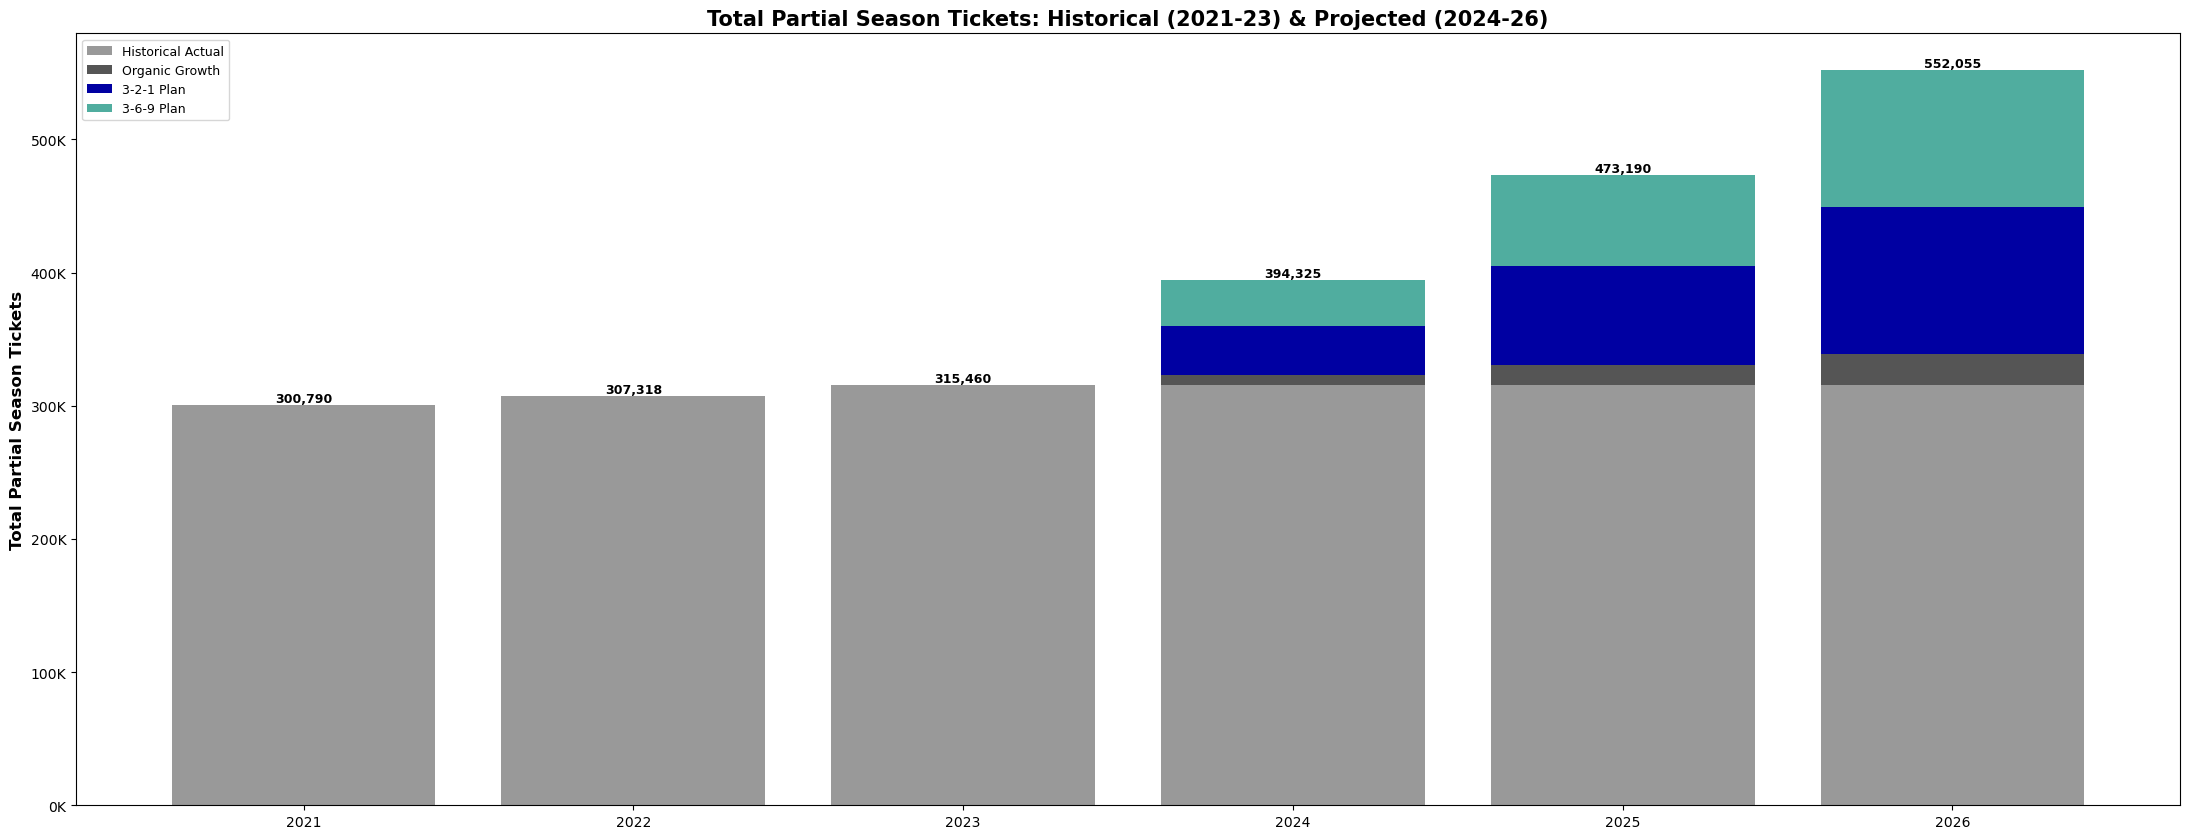

 Year   Total                                                            Source
 2021 300,790                                                 Historical Actual
 2022 307,318                                                 Historical Actual
 2023 315,460                                                 Historical Actual
 2024 394,325    Baseline 315,460 + Organic 7,602 + 3-2-1 36,867 + 3-6-9 34,396
 2025 473,190   Baseline 315,460 + Organic 15,387 + 3-2-1 73,734 + 3-6-9 68,609
 2026 552,055 Baseline 315,460 + Organic 23,360 + 3-2-1 110,601 + 3-6-9 102,634


In [6]:
historical = full.groupby('Year')['Partial Season Tickets (#)'].sum().to_dict()
baseline_2023 = historical[2023]
organic_contribution = {1: 7602, 2: 15387, 3: 23360}
plan_321_contribution = {1: 36867, 2: 73734, 3: 110601}
plan_369_target = {1: 34396, 2: 68609, 3: 102634}  # updated for 75% growth goal

years_labels = ['2021','2022','2023','2024','2025','2026']
fig, ax = plt.subplots(figsize=FIGSIZE)
x = range(6)

hist_vals = [historical[2021], historical[2022], historical[2023], 0, 0, 0]
baseline_vals = [0,0,0, baseline_2023, baseline_2023, baseline_2023]
organic_vals = [0,0,0, organic_contribution[1], organic_contribution[2], organic_contribution[3]]
plan_321_vals = [0,0,0, plan_321_contribution[1], plan_321_contribution[2], plan_321_contribution[3]]
plan_369_vals = [0,0,0, plan_369_target[1], plan_369_target[2], plan_369_target[3]]

ax.bar(x, hist_vals, color='#999999', label='Historical Actual')
ax.bar(x, baseline_vals, color='#999999')
ax.bar(x, organic_vals, bottom=baseline_vals, color='#555555', label='Organic Growth')
ax.bar(x, plan_321_vals, bottom=[b+o for b,o in zip(baseline_vals, organic_vals)], color=PALETTE[0], label='3-2-1 Plan')
ax.bar(x, plan_369_vals, bottom=[b+o+p for b,o,p in zip(baseline_vals, organic_vals, plan_321_vals)], color=PALETTE[2], label='3-6-9 Plan')

for i in range(6):
    total = hist_vals[i]+baseline_vals[i]+organic_vals[i]+plan_321_vals[i]+plan_369_vals[i]
    ax.text(i, total, f'{total:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(years_labels)
ax.set_title('Total Partial Season Tickets: Historical (2021-23) & Projected (2024-26)', **TITLE_STYLE)
ax.set_ylabel('Total Partial Season Tickets', **LABEL_STYLE)
ax.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))
ax.legend(fontsize=9, loc='upper left')

plt.tight_layout()
plt.show()

summary_rows = []
for i, yr in enumerate([2021,2022,2023]):
    summary_rows.append({'Year': yr, 'Total': f'{historical[yr]:,.0f}', 'Source': 'Historical Actual'})
for yr in [1,2,3]:
    total = baseline_2023+organic_contribution[yr]+plan_321_contribution[yr]+plan_369_target[yr]
    summary_rows.append({'Year': 2023+yr, 'Total': f'{total:,.0f}',
                          'Source': f'Baseline {baseline_2023:,.0f} + Organic {organic_contribution[yr]:,.0f} + 3-2-1 {plan_321_contribution[yr]:,.0f} + 3-6-9 {plan_369_target[yr]:,.0f}'})
print(pd.DataFrame(summary_rows).to_string(index=False))

## Sizing: Final Thoughts & Recommendation
Bringing every lever together, organic Partial Season growth, the 3-2-1 Plan, and the 3-6-9 Plan, gets Acme to a 75% Partial Season growth target by 2026, phased evenly over three years.

- **3-2-1 is the anchor lever.** It's grounded in a real, measured Single Game recovery gap (not an assumption), and by Year 3 it accounts for the majority of the total growth target on its own
- **3-6-9 carries the more ambitious, less-proven share of the goal.** Its target is the leftover after organic growth, and 3-2-1 are accounted for, which makes it the most aggressive assumption in this plan and the one most worth revisiting once real Year 1 results come in
- **Price uplift is a real, separate value driver.** Every recovered ticket is worth substantially more as a Partial Season sale than it ever was as Single Game - this isn't just a volume story
- **Even with full recovery, total attendance doesn't fully return to 2021 levels** - Single Game's continued (tapered) decline means this plan stabilizes the trend rather than erasing it entirely

**Recommendation:** launch both plans for the upcoming season at their Year 1 targets, hold Full Season price flat as a parallel test, and treat this as a three-year rebuild - Year 1 is the starting point, not the finish line.